# Notebook 01 — Exploratory Data Analysis (EDA)

Research Questions yang dijawab:
- RQ1: Berapa probabilitas estimasi sebuah PR akan di-merge?
- RQ2: Apakah rata-rata bug report berubah setelah rilis pandas 2.0?
- RQ3: Berapa probabilitas issue membutuhkan >30 hari untuk ditutup?

Member: Muhamad Fharis Arradhien — Data Engineer  (Member A)
Peran: Eksplorasi data, visualisasi distribusi, identifikasi variabel utama

# AI Disclosure

Notebook ini dibuat dengan bantuan Claude AI (Anthropic) untuk:
- Pembersihan data
- Memeriksa apakah implementasi rumus sudah benar atau belum 

Seluruh interpretasi hasil, analisis kontekstual, dan kesimpulan
ditulis secara mandiri tanpa bantuan AI atau semacamnya.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")

print("Library berhasil diimport")

Library berhasil diimport


In [23]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

df = pd.read_csv("../data/clean/dataset.csv", parse_dates=["created_at","closed_at"])
df_iss = pd.read_csv("../data/clean/issues.csv", parse_dates=["created_at","closed_at"])
df_pr = pd.read_csv("../data/clean/pulls.csv", parse_dates=["created_at","closed_at"])

print(f"dataset.csv : {len(df)} baris, {df.shape[1]} kolom")
print(f"issues.csv  : {len(df_iss)} baris")
print(f"pulls.csv   : {len(df_pr)} baris")
print(f"\nKolom: {list(df.columns)}")
df.head(5)

dataset.csv : 8150 baris, 11 kolom
issues.csv  : 5650 baris
pulls.csv   : 2500 baris

Kolom: ['id', 'type', 'state', 'created_at', 'closed_at', 'days_to_close', 'label_names', 'is_bug', 'is_merged', 'year_month', 'year']


,id,type,state,created_at,closed_at,days_to_close,label_names,is_bug,is_merged,year_month,year
0,38870,issue,closed,2020-12-31 23:58:06+00:00,2021-05-17 15:21:56+00:00,136,Dependencies,0,0,2020-12,2020
1,38865,issue,closed,2020-12-31 21:09:45+00:00,2021-02-02 01:42:42+00:00,32,"Visualization,Regression,Needs Tests",0,0,2020-12,2020
2,38862,issue,closed,2020-12-31 18:45:37+00:00,2021-01-31 19:36:22+00:00,31,"CI,Code Style",0,0,2020-12,2020
3,38860,issue,closed,2020-12-31 17:47:15+00:00,2021-06-22 00:34:09+00:00,172,Typing,0,0,2020-12,2020
4,38859,issue,closed,2020-12-31 17:37:55+00:00,2023-06-27 09:36:46+00:00,907,"Docs,Frequency",0,0,2020-12,2020


In [24]:
print("INFO DATASET")
print(df.info())
print(f"\nMISSING VALUES")
print(df.isnull().sum())
print(f"\nSTATISTIK DESKRIPTIF")
df[["days_to_close","is_merged","is_bug"]].describe().round(3)

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8150 entries, 0 to 8149
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   id             8150 non-null   int64              
 1   type           8150 non-null   object             
 2   state          8150 non-null   object             
 3   created_at     8150 non-null   datetime64[ns, UTC]
 4   closed_at      8150 non-null   datetime64[ns, UTC]
 5   days_to_close  8150 non-null   int64              
 6   label_names    7388 non-null   object             
 7   is_bug         8150 non-null   int64              
 8   is_merged      8150 non-null   int64              
 9   year_month     8150 non-null   object             
 10  year           8150 non-null   int64              
dtypes: datetime64[ns, UTC](2), int64(5), object(4)
memory usage: 700.5+ KB
None

MISSING VALUES
id                 0
type               0
state        

,days_to_close,is_merged,is_bug
count,8150.000,8150.000,8150.000
mean,111.886,0.212,0.331
std,280.602,0.409,0.471
min,0.000,0.000,0.000
25%,0.000,0.000,0.000
50%,5.000,0.000,0.000
75%,50.000,0.000,1.000
max,2105.000,1.000,1.000


# Interpretasi — Overview Dataset

Dataset terdiri dari issues dan pull requests dari repositori pandas-dev/pandas.

Variabel utama yang akan digunakan:
- is_merged -> variabel biner (0/1) untuk analisis Bernoulli (RQ1)
- days_to_close -> variabel kontinu untuk analisis Poisson & Monte Carlo (RQ2, RQ3)
- is_bug -> filter untuk analisis bug report rate
- year_month -> untuk analisis time-series (sebelum/sesudah pandas 2.0)

Pandas 2.0 dirilis pada April 2023 — ini akan menjadi titik pemisah untuk uji hipotesis di Notebook 04.

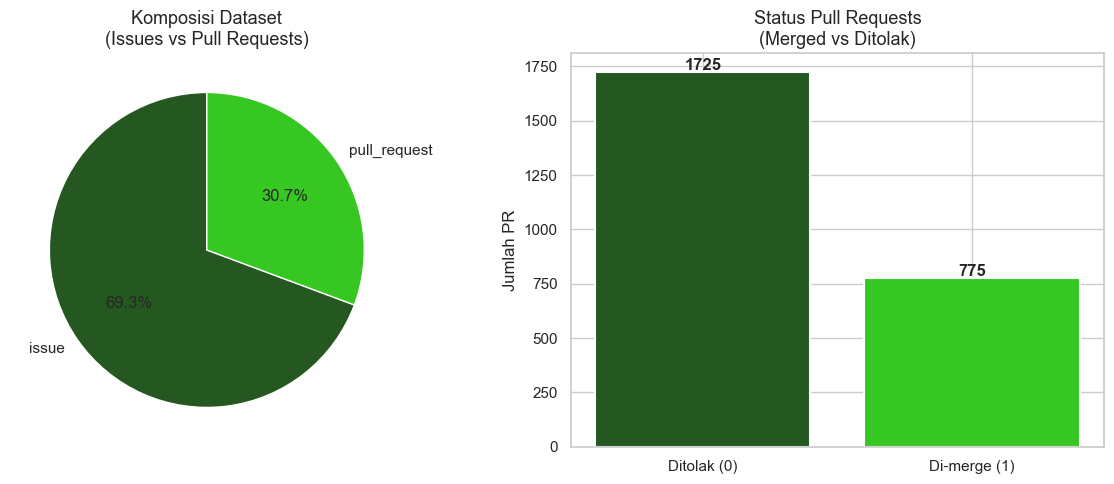


Merge rate PR: 0.6900 (69.00%)
Total PR merged  : 1725
Total PR ditolak : 775


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

type_counts = df["type"].value_counts()
axes[0].pie(type_counts.values, labels=type_counts.index, autopct="%1.1f%%", colors=["#255721","#36C723"], startangle=90)
axes[0].set_title("Komposisi Dataset\n(Issues vs Pull Requests)", fontsize=13)

merge_counts = df_pr["is_merged"].value_counts()
axes[1].bar(["Ditolak (0)", "Di-merge (1)"], merge_counts.values, color=["#255721","#36C723"], edgecolor="white", linewidth=1.5)
axes[1].set_title("Status Pull Requests\n(Merged vs Ditolak)", fontsize=13)
axes[1].set_ylabel("Jumlah PR")
for i, v in enumerate(merge_counts.values):
    axes[1].text(i, v + 10, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

merged_rate = df_pr["is_merged"].mean()
print(f"\nMerge rate PR: {merged_rate:.4f} ({merged_rate*100:.2f}%)")
print(f"Total PR merged  : {df_pr['is_merged'].sum()}")
print(f"Total PR ditolak : {(df_pr['is_merged']==0).sum()}")

# Interpretasi — Merge Rate Pull Request

Dari visualisasi di atas terlihat bahwa sebagian besar PR di pandas-dev/pandas
berhasil di-merge. Nilai merge rate ini akan menjadi input utama untuk :

Notebook 02 -> estimasi MLE Bernoulli (θ̂ = k/n)
Notebook 03 -> confidence interval proporsi
Notebook 04 -> uji hipotesis apakah merge rate berbeda antar periode

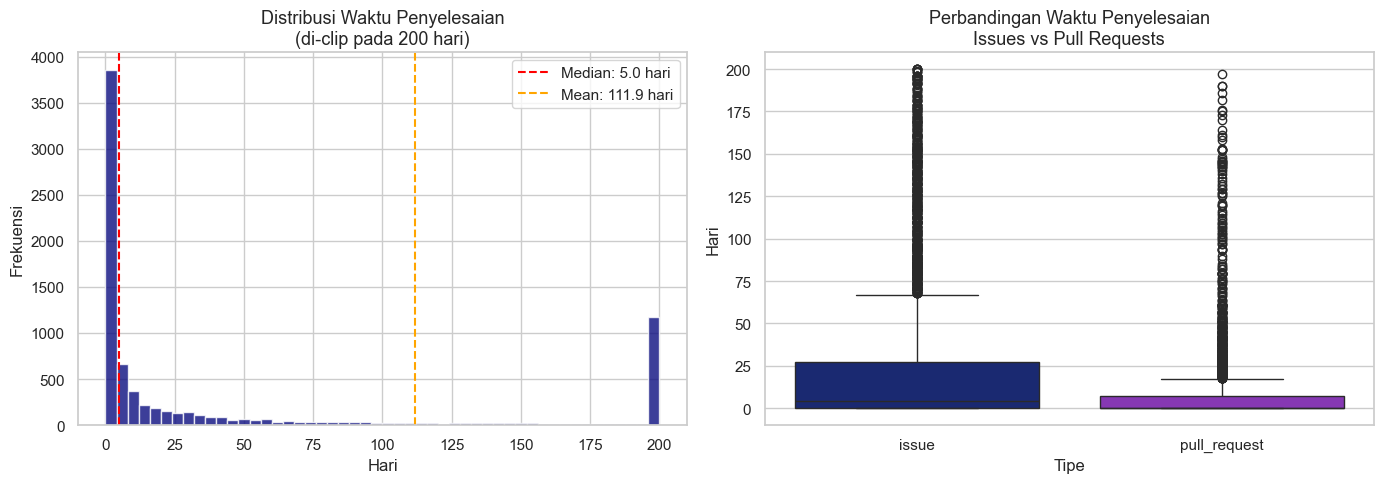

Statistik days_to_close
               count    mean     std  min  25%   50%     75%     max
type                                                                
issue         5650.0  156.75  326.69  0.0  1.0  11.0  123.75  2105.0
pull_request  2500.0   10.49   25.86  0.0  0.0   0.0    7.00   197.0


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["days_to_close"].clip(upper=200), bins=50, color="#0B0D80", edgecolor="white", alpha=0.8)
axes[0].axvline(df["days_to_close"].median(), color="red", linestyle="--", label=f'Median: {df["days_to_close"].median():.1f} hari')
axes[0].axvline(df["days_to_close"].mean(), color="orange", linestyle="--", label=f'Mean: {df["days_to_close"].mean():.1f} hari')
axes[0].set_title("Distribusi Waktu Penyelesaian\n(di-clip pada 200 hari)", fontsize=13)
axes[0].set_xlabel("Hari")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()

df_box = df[df["days_to_close"] <= 200]
sns.boxplot(data=df_box, x="type", y="days_to_close", ax=axes[1], palette=["#0B2080","#8B23C7"])
axes[1].set_title("Perbandingan Waktu Penyelesaian\nIssues vs Pull Requests", fontsize=13)
axes[1].set_xlabel("Tipe")
axes[1].set_ylabel("Hari")

plt.tight_layout()
plt.show()

print("Statistik days_to_close")
print(df.groupby("type")["days_to_close"].describe().round(2))

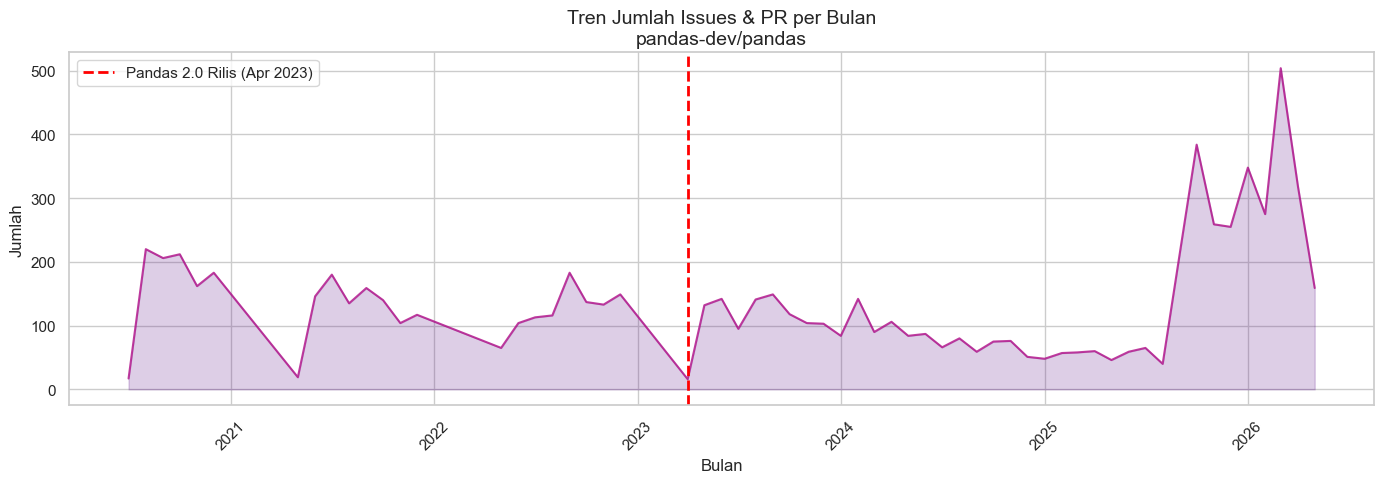

In [27]:
monthly = df.groupby("year_month").size().reset_index(name="count")
monthly["year_month"] = pd.to_datetime(monthly["year_month"])
monthly = monthly.sort_values("year_month")

plt.figure(figsize=(14, 5))
plt.plot(monthly["year_month"], monthly["count"], color="#AF0D87", linewidth=1.5, alpha=0.8)
plt.fill_between(monthly["year_month"], monthly["count"], alpha=0.2, color="#590A86")
plt.axvline(pd.Timestamp("2023-04-01"), color="red", linestyle="--", linewidth=2, label="Pandas 2.0 Rilis (Apr 2023)")
plt.title("Tren Jumlah Issues & PR per Bulan\npandas-dev/pandas", fontsize=14)
plt.xlabel("Bulan")
plt.ylabel("Jumlah")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

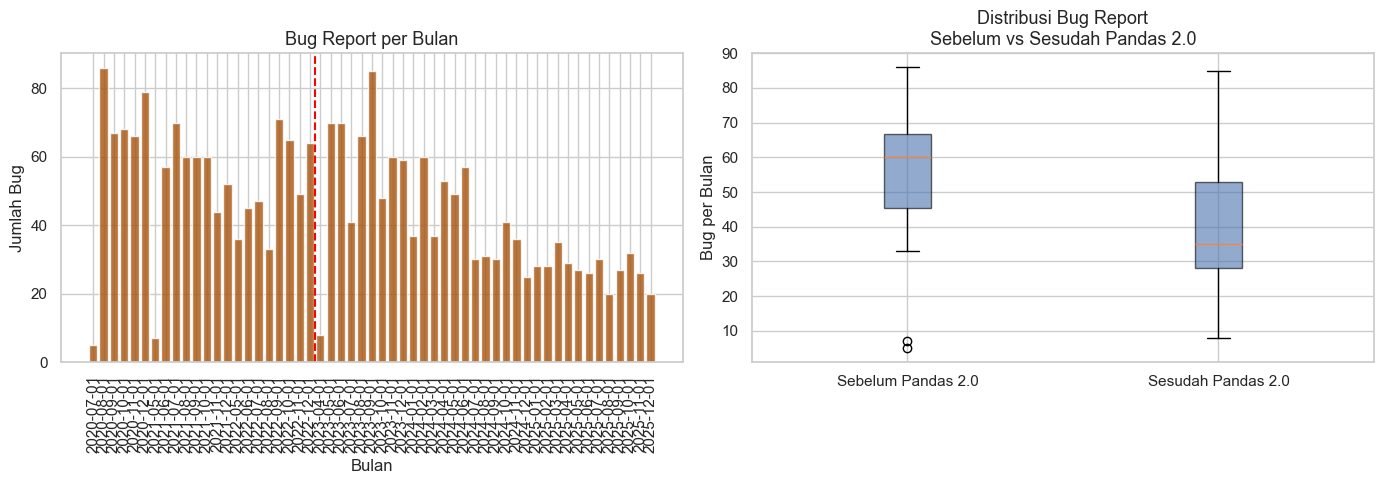

Rata-rata bug/bulan sebelum pandas 2.0 : 54.14
Rata-rata bug/bulan sesudah pandas 2.0  : 40.03


In [28]:
bug_monthly = df_iss.groupby("year_month").agg(total=("id","count"), bugs=("is_bug","sum")).reset_index()
bug_monthly["year_month"] = pd.to_datetime(bug_monthly["year_month"])
bug_monthly = bug_monthly.sort_values("year_month")

cutoff = pd.Timestamp("2023-04-01")
before = bug_monthly[bug_monthly["year_month"] <  cutoff]["bugs"]
after  = bug_monthly[bug_monthly["year_month"] >= cutoff]["bugs"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(bug_monthly["year_month"].astype(str), bug_monthly["bugs"], color="#A8530E", alpha=0.8)
axes[0].axvline(x=bug_monthly[bug_monthly["year_month"]>=cutoff].index[0] - bug_monthly.index[0]-0.5, color="red", linestyle="--", label="Pandas 2.0")
axes[0].set_title("Bug Report per Bulan", fontsize=13)
axes[0].set_xlabel("Bulan")
axes[0].set_ylabel("Jumlah Bug")
axes[0].tick_params(axis="x", rotation=90)

axes[1].boxplot([before.values, after.values], labels=["Sebelum Pandas 2.0", "Sesudah Pandas 2.0"], patch_artist=True, boxprops=dict(facecolor="#4C72B0", alpha=0.6))
axes[1].set_title("Distribusi Bug Report\nSebelum vs Sesudah Pandas 2.0", fontsize=13)
axes[1].set_ylabel("Bug per Bulan")

plt.tight_layout()
plt.show()

print(f"Rata-rata bug/bulan sebelum pandas 2.0 : {before.mean():.2f}")
print(f"Rata-rata bug/bulan sesudah pandas 2.0  : {after.mean():.2f}")

# Summary EDA — Temuan Utama

| Variabel | Nilai | Digunakan di |
- | Merge rate PR | output sel 7 | Notebook 02, 03, 04 |
- | Median days_to_close | output sel 9 | Notebook 05  |
- | Rata-rata bug/bulan (sebelum v2.0) | output sel 11 | Notebook 02, 04 |
- | Rata-rata bug/bulan (sesudah v2.0) | output sel 11 | Notebook 04 |

# Output untuk Layer Berikutnya / Role Berikutnya

Member B (Estimation):
- is_merged dari pulls.csv -> input MLE Bernoulli
- bugs per bulan dari issues.csv -> input MLE Poisson

Member D (Hypothesis):
- Titik pemisah: April 2023 (pandas 2.0 rilis)
- Data sebelum/sesudah tersedia di issues.csv kolom year_month

Member E (Simulation):
- days_to_close dari dataset.csv -> input Monte Carlo
- id dari issues.csv -> input Bloom Filter